# Data

In [ ]:
import time
import pandas as pd
import os
from nba_api.stats.endpoints import leaguegamelog

def fetch_and_save_nba_data(filename="nba_games_jan14_2026.xlsx"):
    # 1. Fetch Data
    seasons = ["2020-21", "2021-22", "2022-23", "2023-24", "2024-25", "2025-26"]
    all_games = []

    print("Fetching NBA game logs...")
    for season in seasons:
        try:
            gamelog = leaguegamelog.LeagueGameLog(
                season=season, 
                season_type_all_star="Regular Season"
            ).get_data_frames()[0]
            
            all_games.append(gamelog)
            print(f"Fetched season {season}")
            time.sleep(0.6)
        except Exception as e:
            print(f"Error fetching {season}: {e}")

    # 2. Combine and Filter
    if all_games:
        games_df = pd.concat(all_games, ignore_index=True)
        games_df['GAME_DATE'] = pd.to_datetime(games_df['GAME_DATE'])
        
        # Filter strictly up to Jan 14, 2026
        cutoff_date = pd.to_datetime("2026-01-16") #16 might be better
        filtered_df = games_df[games_df['GAME_DATE'] <= cutoff_date]
        
        # 3. Save
        filtered_df.to_excel(filename, index=False)
        print(f"Success: {len(filtered_df)} rows saved to {filename}")
    else:
        print("No data fetched.")

# ==============================================================================
# UNCOMMENT THE LINE BELOW TO RUN DATA COLLECTION (Run once, then comment out)
# ==============================================================================
#fetch_and_save_nba_data()

Fetching NBA game logs...
Fetched season 2020-21
Fetched season 2021-22
Fetched season 2022-23
Fetched season 2023-24
Fetched season 2024-25
Fetched season 2025-26
Success: 13234 rows saved to nba_games_jan14_2026.xlsx


In [3]:
import pandas as pd

# Load the saved data
games_df = pd.read_excel("nba_games_jan14_2026.xlsx")

# Ensure GAME_DATE is datetime (crucial for your feature engineering later)
games_df['GAME_DATE'] = pd.to_datetime(games_df['GAME_DATE'])

games_df['HOME_GAME'] = games_df['MATCHUP'].str.contains('vs.').astype(int)

print(f"Loaded {len(games_df)} rows.")
print(f"Date Range: {games_df['GAME_DATE'].min()} to {games_df['GAME_DATE'].max()}")

Loaded 13234 rows.
Date Range: 2020-12-22 00:00:00 to 2026-01-16 00:00:00


In [4]:
# ============================================================
# 2️⃣ FEATURE ENGINEERING
# ============================================================

# --- 1. Merge Team + Opponent ---
opp_df = games_df.rename(columns={c: 'OPP_'+c for c in games_df.columns if c != 'GAME_ID'})
games_df = games_df.merge(opp_df, on='GAME_ID')
games_df = games_df[games_df['TEAM_ABBREVIATION'] != games_df['OPP_TEAM_ABBREVIATION']].reset_index(drop=True)

# --- 2. Normalize ---
games_df['MIN'] = pd.to_numeric(games_df['MIN'], errors='coerce').fillna(240)
for c in ['PTS','AST','REB','OREB','DREB','STL','BLK','TOV','FGA','FGM','FTA','FG3A','FG3M']:
    if c in games_df: games_df[f'{c}_PER48'] = games_df[c] / games_df['MIN'] * 48

# --- 3. Possessions & Ratings ---
est_poss = lambda fga, fta, oreb, tov: fga + 0.44 * fta - oreb + tov
games_df['TEAM_POSSESSIONS'] = est_poss(games_df['FGA'], games_df['FTA'], games_df['OREB'], games_df['TOV'])
games_df['OPP_POSSESSIONS'] = est_poss(games_df['OPP_FGA'], games_df['OPP_FTA'], games_df['OPP_OREB'], games_df['OPP_TOV'])

games_df['PACE'] = 120 * (games_df['TEAM_POSSESSIONS'] + games_df['OPP_POSSESSIONS']) / games_df['MIN']
games_df['OFF_RTG'] = 100 * games_df['PTS'] / games_df['TEAM_POSSESSIONS'].replace(0, 1)
games_df['DEF_RTG'] = 100 * games_df['OPP_PTS'] / games_df['OPP_POSSESSIONS'].replace(0, 1)
games_df['NET_RTG'] = games_df['OFF_RTG'] - games_df['DEF_RTG']

# --- 4. Efficiency & Style ---
fga_adj = games_df['FGA'].replace(0, 1)
games_df['TS_PCT'] = games_df['PTS'] / (2 * (games_df['FGA'] + 0.44 * games_df['FTA'])).replace(0, 1)
games_df['EFG_PCT'] = (games_df['FGM'] + 0.5 * games_df.get('FG3M', 0)) / fga_adj
games_df['TOV_PCT'] = games_df['TOV'] / (games_df['FGA'] + 0.44 * games_df['FTA'] + games_df['TOV']).replace(0, 1)
games_df['REB_PCT'] = games_df['REB'] / (games_df['REB'] + games_df['OPP_REB']).replace(0, 1)

games_df['FG3A_RATE'] = games_df.get('FG3A', 0) / fga_adj
games_df['FTA_RATE'] = games_df['FTA'] / fga_adj
games_df['ORB_PCT'] = games_df['OREB'] / (games_df['OREB'] + games_df['OPP_DREB']).replace(0, 1)

# --- 5. Rankings ---
g_date = games_df.groupby('GAME_DATE')
games_df['OFF_RANK'] = g_date['OFF_RTG'].rank(ascending=False, method='dense')
games_df['DEF_RANK'] = g_date['DEF_RTG'].rank(ascending=True, method='dense')
games_df['NET_RANK'] = g_date['NET_RTG'].rank(ascending=False, method='dense')

# --- 6. Fatigue ---
games_df = games_df.sort_values(['TEAM_ABBREVIATION', 'GAME_DATE'])
games_df['DAYS_SINCE_LAST'] = games_df.groupby('TEAM_ABBREVIATION')['GAME_DATE'].diff().dt.days.fillna(3).clip(0, 7)
games_df['IS_BACK_TO_BACK'] = (games_df['DAYS_SINCE_LAST'] <= 1).astype(int)

# --- 7. Rolling Stats ---
grp = games_df.groupby('TEAM_ABBREVIATION')
cols = ['PACE','OFF_RTG','DEF_RTG','NET_RTG','TS_PCT','EFG_PCT','TOV_PCT','REB_PCT','OFF_RANK','DEF_RANK','NET_RANK','PTS','FG3A_RATE','FTA_RATE','ORB_PCT']
for c in cols:
    shifted = grp[c].shift(1)
    games_df[f'{c}_L5'] = shifted.transform(lambda x: x.rolling(5, min_periods=1).mean())
    games_df[f'{c}_L10'] = shifted.transform(lambda x: x.rolling(10, min_periods=1).mean())

# --- 8. Variance ---
for c in ['PACE', 'TS_PCT', 'EFG_PCT', 'OFF_RTG', 'DEF_RTG', 'FG3A_RATE']:
    shifted = grp[c].shift(1)
    games_df[f'{c}_STD_L5'] = shifted.transform(lambda x: x.rolling(5, min_periods=2).std())
    games_df[f'{c}_STD_L10'] = shifted.transform(lambda x: x.rolling(10, min_periods=3).std())

std_cols = [c for c in games_df if '_STD_' in c]
games_df[std_cols] = games_df[std_cols].fillna(games_df[std_cols].median())

# --- 9. Intensity ---
games_df['OFF_RTG_L5_PCT'] = games_df.groupby('GAME_DATE')['OFF_RTG_L5'].rank(pct=True)
games_df['DEF_RTG_L5_PCT'] = 1 - games_df.groupby('GAME_DATE')['DEF_RTG_L5'].rank(pct=True)
games_df['TEAM_INTENSITY_L5'] = 0.5 * games_df['OFF_RTG_L5_PCT'] + 0.5 * (1 - games_df['DEF_RTG_L5_PCT'])

# --- 10. Matchups ---
home = games_df[games_df['HOME_GAME'] == 1].add_suffix('_HOME').rename(columns={'GAME_ID_HOME': 'GAME_ID'})
away = games_df[games_df['HOME_GAME'] == 0].add_suffix('_AWAY').rename(columns={'GAME_ID_AWAY': 'GAME_ID'})
matchup_df = pd.merge(home, away, on='GAME_ID')

# --- 11. Interactions ---
for c in ['PACE', 'FG3A_RATE', 'FTA_RATE', 'ORB_PCT', 'OFF_RTG']:
    matchup_df[f'{c}_L5_MEAN'] = (matchup_df[f'{c}_L5_HOME'] + matchup_df[f'{c}_L5_AWAY']) / 2

matchup_df['GAME_VOLATILITY'] = sum(matchup_df[f'{c}_STD_L10_{side}'] for c in ['PACE', 'TS_PCT', 'OFF_RTG'] for side in ['HOME', 'AWAY'])
matchup_df['PACE_DIFF'] = matchup_df['PACE_L10_HOME'] - matchup_df['PACE_L10_AWAY']
matchup_df['NET_RANK_DIFF'] = matchup_df['NET_RANK_L10_HOME'] - matchup_df['NET_RANK_L10_AWAY']
matchup_df['NET_RANK_GAP'] = abs(matchup_df['NET_RANK_L5_HOME'] - matchup_df['NET_RANK_L5_AWAY'])

print("✅ Feature Engineering Complete")

✅ Feature Engineering Complete


C:\Users\Varic\AppData\Local\Temp\ipykernel_15884\922266896.py:56: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  matchup_df["EXPANDING_SCALE"].fillna(matchup_df["TOTAL_PTS"].mean() / matchup_df["LINE_RAW"].mean(), inplace=True)


✅ Line Construction Complete
MAE: 16.83 | RMSE: 21.15 | Over%: 48.2%
Correlation: 0.120


C:\Users\Varic\AppData\Local\Temp\ipykernel_15884\922266896.py:80: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  err_grp = matchup_df.groupby("LINE_BUCKET")["ERROR"].agg(['mean', 'std']).reset_index()


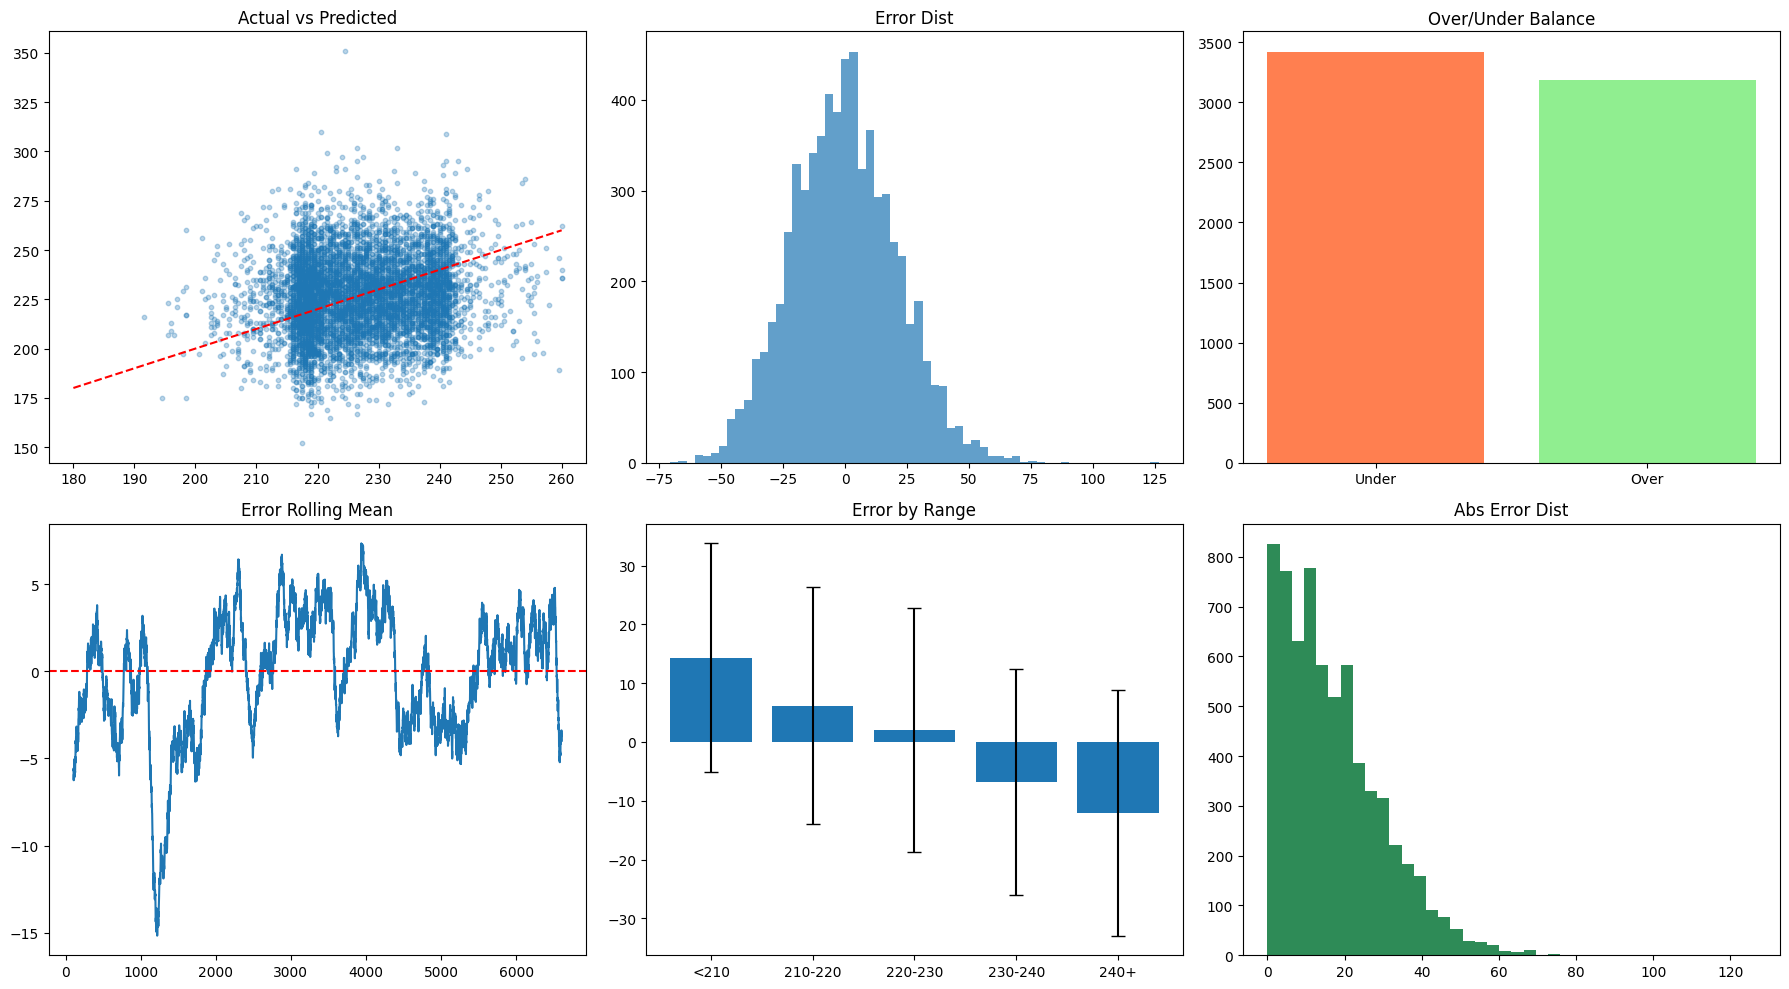

In [5]:
# ============================================================
# 3️⃣ ENHANCED LINE CONSTRUCTION
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import spearmanr

# --- 1. Base Metrics ---
matchup_df["TOTAL_PTS"] = matchup_df["PTS_HOME"] + matchup_df["PTS_AWAY"]
matchup_df["HOME_WIN"] = (matchup_df["WL_HOME"] == "W").astype(int)

# Pace & Volatility
matchup_df["EXP_PACE"] = sum(0.7 * matchup_df[f"PACE_L5_{s}"] + 0.3 * matchup_df[f"PACE_L10_{s}"] for s in ['HOME', 'AWAY']) / 2
matchup_df["PACE_VOLATILITY"] = (matchup_df["PACE_STD_L5_HOME"] + matchup_df["PACE_STD_L5_AWAY"]) / 2
matchup_df["PACE_VOL_ADJ"] = matchup_df["PACE_VOLATILITY"] * 0.3

# Fatigue
matchup_df["PACE_FATIGUE_ADJ"] = -2.0 * (matchup_df["IS_BACK_TO_BACK_HOME"] + matchup_df["IS_BACK_TO_BACK_AWAY"])
matchup_df["REST_ADVANTAGE"] = (matchup_df["DAYS_SINCE_LAST_HOME"].clip(0, 5) - matchup_df["DAYS_SINCE_LAST_AWAY"].clip(0, 5)) * 0.1
matchup_df["EXP_PACE_ADJ"] = matchup_df["EXP_PACE"] + matchup_df["PACE_FATIGUE_ADJ"] + matchup_df["PACE_VOL_ADJ"]

# Efficiency (PPP)
for side in ['HOME', 'AWAY']:
    for stat in ['OFF_RTG', 'DEF_RTG']:
        matchup_df[f"{stat}_{side}_WEIGHTED"] = 0.65 * matchup_df[f"{stat}_L5_{side}"] + 0.35 * matchup_df[f"{stat}_L10_{side}"]

matchup_df["EXP_PPP_HOME"] = matchup_df["OFF_RTG_HOME_WEIGHTED"] / matchup_df["DEF_RTG_AWAY_WEIGHTED"].replace(0, 1)
matchup_df["EXP_PPP_AWAY"] = matchup_df["OFF_RTG_AWAY_WEIGHTED"] / matchup_df["DEF_RTG_HOME_WEIGHTED"].replace(0, 1)
matchup_df["EXP_PPP"] = (matchup_df["EXP_PPP_HOME"] + matchup_df["EXP_PPP_AWAY"]) / 2

# --- 2. Style Adjustments ---
factors = [
    ("THREE_PT", "FG3A_RATE", 0.35, 8), ("FTA", "FTA_RATE", 0.25, 6),
    ("ORB", "ORB_PCT", 0.25, 10), ("TOV", "TOV_PCT", 0.13, -15)
]
for name, col, base, mult in factors:
    matchup_df[f"{name}_FACTOR"] = (matchup_df[f"{col}_L5_HOME"] + matchup_df[f"{col}_L5_AWAY"]) / 2
    matchup_df[f"{name}_ADJ"] = (matchup_df[f"{name}_FACTOR"] - base) * mult

matchup_df["SHOOTING_EFFICIENCY"] = (matchup_df["TS_PCT_L5_HOME"] + matchup_df["TS_PCT_L5_AWAY"]) / 2
matchup_df["SHOOTING_ADJ"] = (matchup_df["SHOOTING_EFFICIENCY"] - 0.56) * 50
matchup_df["MISMATCH_FACTOR"] = matchup_df["NET_RANK_GAP"] / 30
matchup_df["MISMATCH_ADJ"] = matchup_df["MISMATCH_FACTOR"] * 1.5

# --- 3. Line Construction ---
SCALING_FACTOR = 2.31
matchup_df["RAW_EXPECTED_TOTAL"] = matchup_df["EXP_PACE_ADJ"] * matchup_df["EXP_PPP"] * SCALING_FACTOR
matchup_df["TOTAL_ADJUSTMENTS"] = sum(matchup_df[f"{k}_ADJ"] for k in ["THREE_PT", "FTA", "ORB", "TOV", "SHOOTING", "MISMATCH"]) + matchup_df["REST_ADVANTAGE"]
matchup_df["LINE_RAW"] = matchup_df["RAW_EXPECTED_TOTAL"] + matchup_df["TOTAL_ADJUSTMENTS"]

# Calibration
matchup_df = matchup_df.sort_values("GAME_DATE_HOME").reset_index(drop=True)
matchup_df["EXPANDING_SCALE"] = [matchup_df.loc[:i-1, "TOTAL_PTS"].mean() / matchup_df.loc[:i-1, "LINE_RAW"].mean() if i >= 50 else np.nan for i in range(len(matchup_df))]
matchup_df["EXPANDING_SCALE"].fillna(matchup_df["TOTAL_PTS"].mean() / matchup_df["LINE_RAW"].mean(), inplace=True)
matchup_df["LINE_CALIBRATED"] = matchup_df["LINE_RAW"] * matchup_df["EXPANDING_SCALE"]

# Range Adjustment & Finalization
def adj_range(x): return x + 8 if x < 210 else x + 4 if x < 215 else x - 8 if x > 245 else x - 4 if x > 240 else x
matchup_df["LINE_RANGE_ADJ"] = matchup_df["LINE_CALIBRATED"].apply(adj_range)
matchup_df["LINE_ROUNDED"] = (matchup_df["LINE_RANGE_ADJ"] * 2).round() / 2
matchup_df["LINE_BOUNDED"] = matchup_df["LINE_ROUNDED"].clip(180, 260)
matchup_df["LINE"] = ((matchup_df["LINE_BOUNDED"] - (matchup_df["LINE_BOUNDED"] - matchup_df["TOTAL_PTS"]).mean()) * 2).round() / 2
matchup_df["LINE"] = matchup_df["LINE"].clip(180, 260)
matchup_df["OVER"] = (matchup_df["TOTAL_PTS"] > matchup_df["LINE"]).astype(int)
matchup_df["ERROR"] = matchup_df["TOTAL_PTS"] - matchup_df["LINE"]

# --- 4. Analysis & Plots ---
print(f"✅ Line Construction Complete\nMAE: {matchup_df['ERROR'].abs().mean():.2f} | RMSE: {np.sqrt((matchup_df['ERROR']**2).mean()):.2f} | Over%: {matchup_df['OVER'].mean()*100:.1f}%")
valid = np.isfinite(matchup_df["LINE"]) & np.isfinite(matchup_df["TOTAL_PTS"])
print(f"Correlation: {spearmanr(matchup_df.loc[valid, 'LINE'], matchup_df.loc[valid, 'TOTAL_PTS'])[0]:.3f}")

matchup_df["LINE_BUCKET"] = pd.cut(matchup_df["LINE"], bins=[0, 210, 220, 230, 240, 300], labels=["<210", "210-220", "220-230", "230-240", "240+"])
fig, ax = plt.subplots(2, 3, figsize=(18, 10))
ax[0,0].scatter(matchup_df["LINE"], matchup_df["TOTAL_PTS"], alpha=0.3, s=10); ax[0,0].plot([180, 260], [180, 260], 'r--'); ax[0,0].set_title('Actual vs Predicted')
ax[0,1].hist(matchup_df["ERROR"], bins=60, alpha=0.7); ax[0,1].set_title('Error Dist')
ax[0,2].bar(['Under', 'Over'], matchup_df["OVER"].value_counts().sort_index(), color=['coral', 'lightgreen']); ax[0,2].set_title('Over/Under Balance')
ax[1,0].plot(matchup_df["ERROR"].rolling(100).mean()); ax[1,0].axhline(0, c='r', ls='--'); ax[1,0].set_title('Error Rolling Mean')
err_grp = matchup_df.groupby("LINE_BUCKET")["ERROR"].agg(['mean', 'std']).reset_index()
ax[1,1].bar(err_grp["LINE_BUCKET"].astype(str), err_grp["mean"], yerr=err_grp["std"], capsize=5); ax[1,1].set_title('Error by Range')
ax[1,2].hist(matchup_df["ERROR"].abs(), bins=40, color='seagreen'); ax[1,2].set_title('Abs Error Dist')
plt.tight_layout(); plt.show()

✅ Features prepared. Shape: (6679, 22)


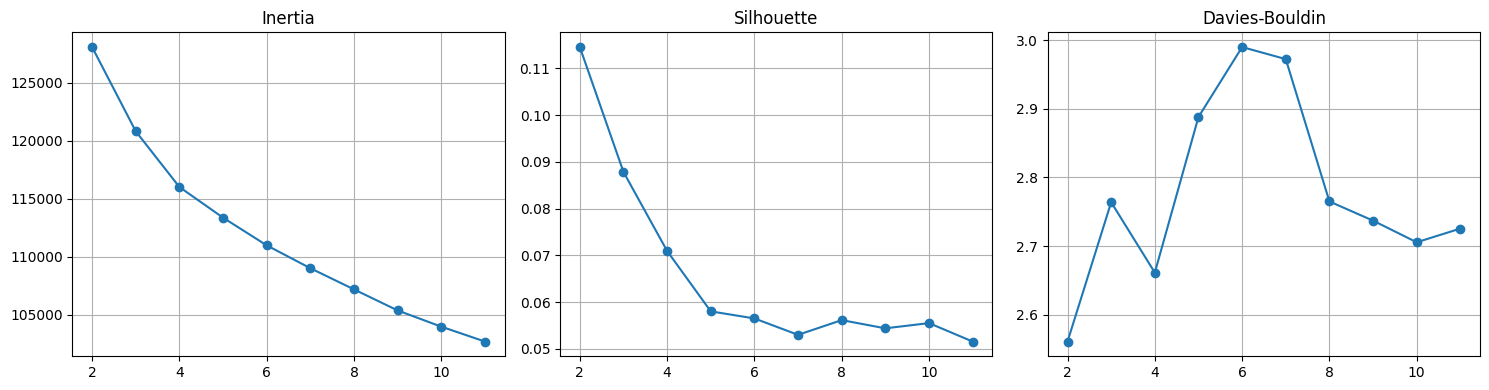

k=2: Sil=0.115, DB=2.561
k=3: Sil=0.088, DB=2.764
k=4: Sil=0.071, DB=2.661
k=5: Sil=0.058, DB=2.888
k=6: Sil=0.056, DB=2.990
k=7: Sil=0.053, DB=2.972
k=8: Sil=0.056, DB=2.765
k=9: Sil=0.054, DB=2.737
k=10: Sil=0.056, DB=2.705
k=11: Sil=0.052, DB=2.725

🎯 Dist: {0: 2112, 1: 2017, 2: 2550}
        PACE_L5_MEAN  COMBINED_OFF_RTG_L5  COMBINED_DEF_RTG_L5  \
REGIME                                                           
0             101.64               219.90               230.41   
1             101.09               214.57               215.24   
2             101.18               231.42               222.18   

        FG3A_RATE_L5_MEAN  TOTAL_VOLATILITY_L5  OFF_DEF_ADVANTAGE  \
REGIME                                                              
0                    0.40                28.78              -5.25   
1                    0.40                28.03              -0.33   
2                    0.41                28.47               4.62   

        NET_RANK_GAP  
REGIME     

In [4]:
# ============================================================
# 4️⃣ IMPROVED REGIME CLUSTERING
# ============================================================

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
import matplotlib.pyplot as plt

# --- 1. Interaction Features ---
matchup_df['PACE_L5_MEAN'] = (matchup_df['PACE_L5_HOME'] + matchup_df['PACE_L5_AWAY']) / 2
matchup_df['PACE_L5_DIFF'] = matchup_df['PACE_L5_HOME'] - matchup_df['PACE_L5_AWAY']
matchup_df['COMBINED_OFF_RTG_L5'] = matchup_df['OFF_RTG_L5_HOME'] + matchup_df['OFF_RTG_L5_AWAY']
matchup_df['COMBINED_DEF_RTG_L5'] = matchup_df['DEF_RTG_L5_HOME'] + matchup_df['DEF_RTG_L5_AWAY']
matchup_df['OFF_DEF_ADVANTAGE'] = ((matchup_df['OFF_RTG_L5_HOME'] - matchup_df['DEF_RTG_L5_AWAY']) + (matchup_df['OFF_RTG_L5_AWAY'] - matchup_df['DEF_RTG_L5_HOME'])) / 2

for c in ['FG3A_RATE', 'FTA_RATE', 'ORB_PCT', 'TS_PCT', 'EFG_PCT', 'TOV_PCT']:
    matchup_df[f'{c}_L5_MEAN'] = (matchup_df[f'{c}_L5_HOME'] + matchup_df[f'{c}_L5_AWAY']) / 2

matchup_df['TOTAL_VOLATILITY_L5'] = sum(matchup_df[f'{c}_STD_L5_{s}'] for c in ['PACE', 'TS_PCT', 'OFF_RTG', 'FG3A_RATE'] for s in ['HOME', 'AWAY'])
matchup_df['NET_RANK_GAP'] = abs(matchup_df['NET_RANK_L5_HOME'] - matchup_df['NET_RANK_L5_AWAY'])
matchup_df['FATIGUE_FACTOR'] = matchup_df['IS_BACK_TO_BACK_HOME'] + matchup_df['IS_BACK_TO_BACK_AWAY']

# --- 2. Clustering Setup ---
regime_features = [
    "PACE_L5_MEAN", "COMBINED_OFF_RTG_L5", "COMBINED_DEF_RTG_L5", "FG3A_RATE_L5_MEAN", "TS_PCT_L5_MEAN", "EFG_PCT_L5_MEAN",
    "FTA_RATE_L5_MEAN", "ORB_PCT_L5_MEAN", "OFF_DEF_ADVANTAGE", "PACE_L5_DIFF", "NET_RANK_GAP", "TOTAL_VOLATILITY_L5",
    "PACE_STD_L5_HOME", "PACE_STD_L5_AWAY", "FG3A_RATE_STD_L5_HOME", "FG3A_RATE_STD_L5_AWAY", "TOV_PCT_L5_MEAN", "FATIGUE_FACTOR",
    "OFF_RTG_L5_HOME", "OFF_RTG_L5_AWAY", "DEF_RTG_L5_HOME", "DEF_RTG_L5_AWAY"
]

regime_df = matchup_df[regime_features].dropna().copy()
X_regime_scaled = StandardScaler().fit_transform(regime_df)
print(f"✅ Features prepared. Shape: {X_regime_scaled.shape}")

# --- 3. Optimal Clusters ---
inertias, silhouettes, db_scores = [], [], []
K_range = range(2, 12)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=20, max_iter=500).fit(X_regime_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_regime_scaled, km.labels_))
    db_scores.append(davies_bouldin_score(X_regime_scaled, km.labels_))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, data, title in zip(axes, [inertias, silhouettes, db_scores], ['Inertia', 'Silhouette', 'Davies-Bouldin']):
    ax.plot(K_range, data, 'o-'); ax.set_title(title); ax.grid(True)
plt.tight_layout(); plt.show()

for k, s, d in zip(K_range, silhouettes, db_scores): print(f"k={k}: Sil={s:.3f}, DB={d:.3f}")

# --- 4. Final Model & Labeling ---
optimal_k = 3
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=20).fit(X_regime_scaled)
regime_df['REGIME'] = kmeans_final.labels_

print(f"\n🎯 Dist: {regime_df['REGIME'].value_counts().sort_index().to_dict()}")
regime_summary = regime_df.groupby('REGIME')[['PACE_L5_MEAN', 'COMBINED_OFF_RTG_L5', 'COMBINED_DEF_RTG_L5', 'FG3A_RATE_L5_MEAN', 'TOTAL_VOLATILITY_L5', 'OFF_DEF_ADVANTAGE', 'NET_RANK_GAP']].mean()
print(regime_summary.round(2))

def label_regime(row):
    q = regime_summary.quantile([0.25, 0.75])
    if row['PACE_L5_MEAN'] > q.loc[0.75, 'PACE_L5_MEAN'] and row['COMBINED_OFF_RTG_L5'] > q.loc[0.75, 'COMBINED_OFF_RTG_L5']: return "High-Scoring Shootout"
    if row['PACE_L5_MEAN'] < q.loc[0.25, 'PACE_L5_MEAN'] and row['COMBINED_DEF_RTG_L5'] < q.loc[0.25, 'COMBINED_DEF_RTG_L5']: return "Defensive Grind"
    if row['FG3A_RATE_L5_MEAN'] > q.loc[0.75, 'FG3A_RATE_L5_MEAN'] and row['TOTAL_VOLATILITY_L5'] > q.loc[0.75, 'TOTAL_VOLATILITY_L5']: return "Volatile Three-Point Game"
    if row['COMBINED_OFF_RTG_L5'] > regime_summary['COMBINED_OFF_RTG_L5'].median() and row['COMBINED_DEF_RTG_L5'] < regime_summary['COMBINED_DEF_RTG_L5'].median(): return "Balanced Elite"
    if row['NET_RANK_GAP'] > q.loc[0.75, 'NET_RANK_GAP']: return "Mismatch/Blowout Risk"
    return "Standard Game"

regime_summary['REGIME_LABEL'] = regime_summary.apply(label_regime, axis=1)
print(f"\n🏷️ Labels:\n{regime_summary[['REGIME_LABEL']]}")
matchup_df = matchup_df.merge(regime_df[['REGIME']], left_index=True, right_index=True, how='left')
print("✅ Regime clustering complete.")

In [5]:
# ============================================================
# 5️⃣ FINAL REGIME CLUSTERING (Original)
# ============================================================

k_final = 3
kmeans_final = KMeans(n_clusters=k_final, random_state=42, n_init=20)

# Fit, predict, and assign (handling alignment and NaNs automatically)
matchup_df["REGIME_ID"] = pd.Series(kmeans_final.fit_predict(X_regime_scaled), index=regime_df.index).astype("Int64")

print(f"✅ REGIME_ID assigned (k={k_final})\n{matchup_df['REGIME_ID'].value_counts(dropna=False).sort_index()}")

✅ REGIME_ID assigned (k=3)
REGIME_ID
0       2112
1       2017
2       2550
<NA>       1
Name: count, dtype: Int64


In [6]:
# ============================================================
# 🔍 REGIME INTERPRETATION
# ============================================================

regime_core_summary = matchup_df.dropna(subset=["REGIME_ID"]).groupby("REGIME_ID")[regime_features].agg(["mean", "std"]).round(2)
display(regime_core_summary)

PACE_L5_MEAN       COMBINED_OFF_RTG_L5       COMBINED_DEF_RTG_L5  \
                  mean   std                mean   std                mean   
REGIME_ID                                                                    
0               101.64  2.14              219.90  5.95              230.41   
1               101.09  2.11              214.57  6.20              215.24   
2               101.18  2.04              231.42  5.56              222.18   

                FG3A_RATE_L5_MEAN       TS_PCT_L5_MEAN        ...  \
            std              mean   std           mean   std  ...   
REGIME_ID                                                     ...   
0          5.78              0.40  0.04           0.57  0.02  ...   
1          6.09              0.40  0.04           0.56  0.02  ...   
2          7.46              0.41  0.04           0.60  0.02  ...   

          FATIGUE_FACTOR       OFF_RTG_L5_HOME       OFF_RTG_L5_AWAY        \
                    mean   std            mean   std            mean   std   
REGIME_ID                                                                    
0                   0.37  0.59          110.03  5.28          109.87  5.33   
1                   0.35  0.56          107.26  5.18          107.32  5.25   
2                   0.35  0.57          115.66  4.98          115.77  4.97   

          DEF_RTG_L5_HOME       DEF_RTG_L5_AWAY        
                     mean   std            mean   std  
REGIME_ID                                              
0                  115.11  5.14          115.30  4.88  
1                  107.69  5.24          107.55  5.23  
2                  111.09  5.54          111.09  5.48  

[3 rows x 44 columns]

In [7]:
# ============================================================
# 📊 REGIME BEHAVIOR
# ============================================================

regime_outcome_summary = matchup_df.dropna(subset=["REGIME_ID"]).groupby("REGIME_ID").agg(
    avg_total_pts=("TOTAL_PTS", "mean"), 
    std_total_pts=("TOTAL_PTS", "std"), 
    over_rate=("OVER", "mean")
).round(2)

display(regime_outcome_summary)

,avg_total_pts,std_total_pts,over_rate
REGIME_ID,,,
0,228.94,19.85,0.66
1,221.07,19.90,0.41
2,229.50,19.66,0.39


# Model 1

In [8]:
# ============================================================
# 6️⃣ GAME-LEVEL TRAIN / TEST SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

df_model = matchup_df.dropna(subset=["REGIME_ID"]).copy()
train_ids, test_ids = train_test_split(df_model["GAME_ID"].unique(), test_size=0.2, random_state=42)

train_df, test_df = [df_model[df_model["GAME_ID"].isin(ids)].copy() for ids in (train_ids, test_ids)]

assert set(train_df["GAME_ID"]).isdisjoint(test_df["GAME_ID"])
print(f"✅ Split Complete\nTrain: {train_df['GAME_ID'].nunique()} | Test: {test_df['GAME_ID'].nunique()}")

✅ Split Complete
Train: 5343 | Test: 1336


In [9]:
# ============================================================
# 7️⃣ OVER / UNDER FEATURE SET
# ============================================================

sides, periods = ['HOME', 'AWAY'], ['L5', 'L10']
base_stats = ['PACE', 'OFF_RTG', 'DEF_RTG', 'NET_RTG', 'OFF_RANK', 'DEF_RANK', 'TS_PCT', 'EFG_PCT', 'FG3A_RATE', 'FTA_RATE', 'ORB_PCT', 'TOV_PCT', 'REB_PCT']
vol_stats = ['TS_PCT', 'OFF_RTG', 'FG3A_RATE']
interact_stats = ['PACE', 'FG3A_RATE', 'FTA_RATE', 'ORB_PCT', 'OFF_RTG', 'TS_PCT', 'EFG_PCT', 'TOV_PCT']

ou_features = (
    [f"{s}_{p}_{side}" for side in sides for p in periods for s in base_stats] +
    [f"NET_RANK_L10_{side}" for side in sides] +
    [f"PACE_STD_{p}_{side}" for side in sides for p in periods] +
    [f"{s}_STD_L5_{side}" for side in sides for s in vol_stats] +
    [f"{s}_{side}" for side in sides for s in ["DAYS_SINCE_LAST", "IS_BACK_TO_BACK"]] +
    [f"{s}_L5_MEAN" for s in interact_stats] +
    ["COMBINED_OFF_RTG_L5", "COMBINED_DEF_RTG_L5", "OFF_DEF_ADVANTAGE", "PACE_L5_DIFF", "NET_RANK_GAP", 
     "TOTAL_VOLATILITY_L5", "GAME_VOLATILITY", "PACE_DIFF", "NET_RANK_DIFF", "FATIGUE_FACTOR", "LINE"]
)

print(f"✅ Enhanced ou_features defined: {len(ou_features)} features")

✅ Enhanced ou_features defined: 87 features


In [11]:
from sklearn.ensemble import RandomForestClassifier

# Define the dictionary
ou_models_by_regime = {}

print("Training Over/Under Models...")

# Loop through each regime found in the training data
for rid in sorted(train_df["REGIME_ID"].dropna().unique()):
    # Get training data for this specific regime
    t_df = train_df[train_df["REGIME_ID"] == rid]
    
    # Only train if we have enough samples (e.g., > 50)
    if len(t_df) > 50:
        clf = RandomForestClassifier(n_estimators=300, min_samples_leaf=15, random_state=42, n_jobs=-1)
        clf.fit(t_df[ou_features].fillna(0), t_df["OVER"])
        
        # Store the trained model in the dictionary
        ou_models_by_regime[int(rid)] = clf
        print(f"✅ Regime {int(rid)} O/U model trained")

print("\nFixed! 'ou_models_by_regime' is now defined.")

Training Over/Under Models...
✅ Regime 0 O/U model trained
✅ Regime 1 O/U model trained
✅ Regime 2 O/U model trained

Fixed! 'ou_models_by_regime' is now defined.


In [12]:
# ============================================================
# 8️⃣ REGIME-SPECIFIC EVALUATION
# ============================================================

from sklearn.metrics import accuracy_score

print("\n📊 Over / Under Accuracy by Regime (TEST SET)\n" + "="*46 + "\n")

regime_results = []
for rid, model in ou_models_by_regime.items():
    test_r = test_df[test_df["REGIME_ID"] == rid]
    if test_r.empty:
        print(f"⚠️ Regime {rid}: No samples"); continue

    acc = accuracy_score(test_r["OVER"], model.predict(test_r[ou_features].fillna(0)))
    regime_results.append({"REGIME_ID": rid, "Accuracy": round(acc, 3), "Samples": len(test_r)})
    print(f"Regime {rid}: Acc = {acc:.3f} | N = {len(test_r)}")

print("\n📊 Performance Summary:")
display(pd.DataFrame(regime_results).sort_values("Accuracy", ascending=False))


📊 Over / Under Accuracy by Regime (TEST SET)

Regime 0: Acc = 0.636 | N = 426
Regime 1: Acc = 0.627 | N = 397
Regime 2: Acc = 0.624 | N = 513

📊 Performance Summary:


,REGIME_ID,Accuracy,Samples
0,0,0.636,426
1,1,0.627,397
2,2,0.624,513


In [13]:
sides = ['HOME', 'AWAY']
win_features = (
    [f"{s}_L5_{side}" for side in sides for s in ['NET_RTG', 'OFF_RTG', 'DEF_RTG']] +
    [f"NET_RTG_L10_{side}" for side in sides] +
    ["NET_RANK_DIFF", "NET_RANK_GAP", "PACE_DIFF"] +
    [f"{s}_{side}" for side in sides for s in ["DAYS_SINCE_LAST", "IS_BACK_TO_BACK"]]
)


🏆 REGIME 0 | N=2112 | Acc=0.655
--------------------------------------------------
              precision    recall  f1-score   support

        Away       0.64      0.56      0.59       192
        Home       0.67      0.74      0.70       231

    accuracy                           0.65       423
   macro avg       0.65      0.65      0.65       423
weighted avg       0.65      0.65      0.65       423


🏆 REGIME 1 | N=2017 | Acc=0.636
--------------------------------------------------
              precision    recall  f1-score   support

        Away       0.63      0.54      0.58       190
        Home       0.64      0.72      0.68       214

    accuracy                           0.64       404
   macro avg       0.64      0.63      0.63       404
weighted avg       0.64      0.64      0.63       404


🏆 REGIME 2 | N=2550 | Acc=0.647
--------------------------------------------------
              precision    recall  f1-score   support

        Away       0.67      0.38      

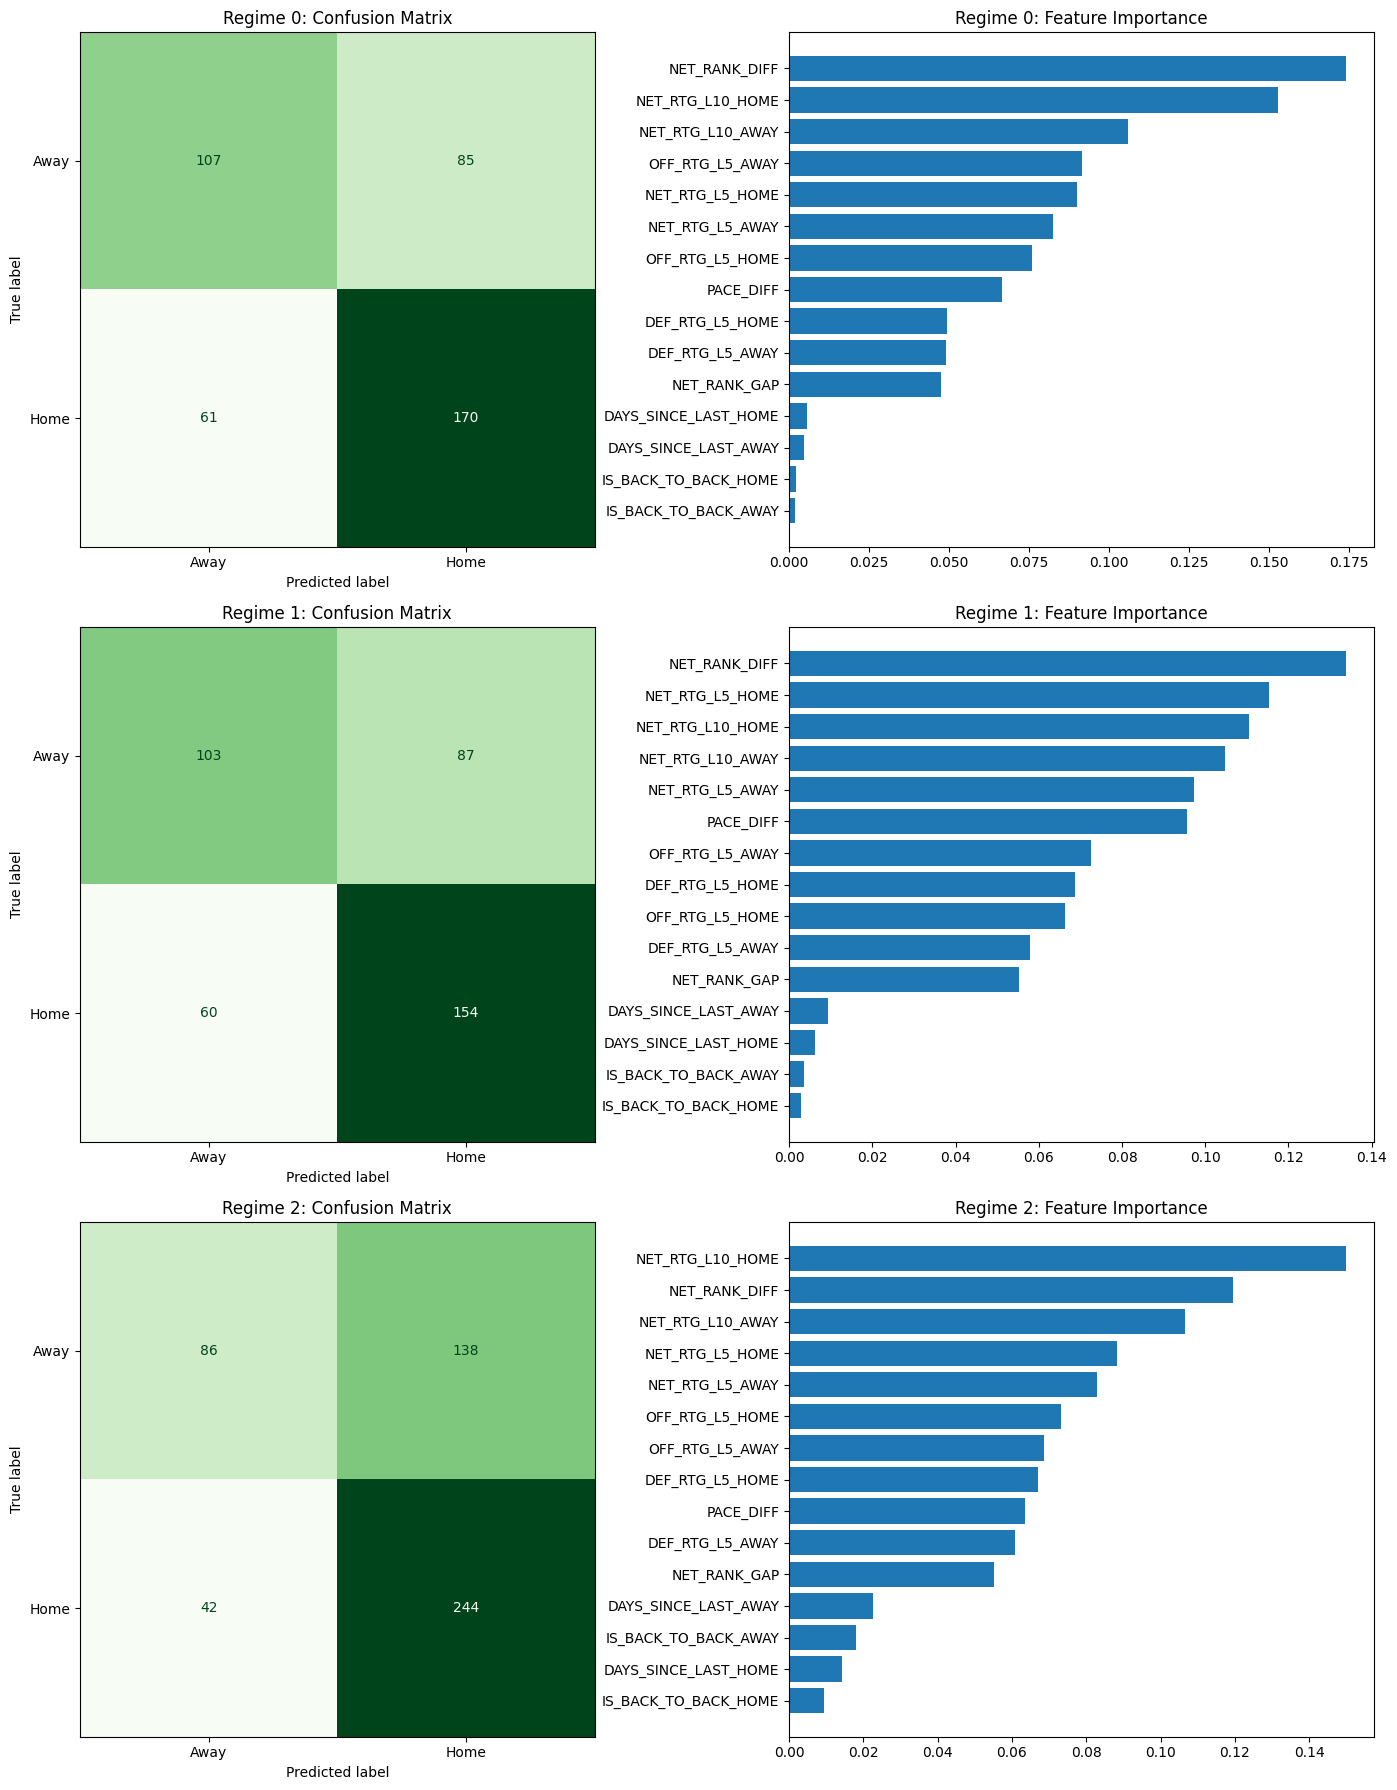

In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

winner_df = matchup_df.dropna(subset=["REGIME_ID"]).copy()
winner_df["REGIME_ID"] = winner_df["REGIME_ID"].astype(int)

# Filter regimes with enough data
valid_regimes = [r for r in sorted(winner_df["REGIME_ID"].unique()) if len(winner_df[winner_df["REGIME_ID"] == r]) >= 200]

cluster_models, cluster_results = {}, []
fig, axes = plt.subplots(len(valid_regimes), 2, figsize=(14, 6 * len(valid_regimes)))
axes = np.atleast_2d(axes)  # Handle single regime case

for i, regime_id in enumerate(valid_regimes):
    cluster_df = winner_df[winner_df["REGIME_ID"] == regime_id]
    X_train, X_test, y_train, y_test = train_test_split(
        cluster_df[win_features].fillna(0), cluster_df["HOME_WIN"], test_size=0.2, shuffle=False
    )

    rf_win = RandomForestClassifier(n_estimators=400, min_samples_leaf=20, random_state=42, n_jobs=-1).fit(X_train, y_train)
    y_pred = rf_win.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    cluster_models[regime_id] = rf_win
    cluster_results.append({"REGIME_ID": regime_id, "SAMPLES": len(cluster_df), "ACCURACY": round(acc, 3)})

    print(f"\n🏆 REGIME {regime_id} | N={len(cluster_df)} | Acc={acc:.3f}\n" + "-"*50)
    print(classification_report(y_test, y_pred, target_names=["Away", "Home"]))

    # Subplots
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=["Away", "Home"], cmap="Greens", ax=axes[i, 0], colorbar=False)
    axes[i, 0].set_title(f"Regime {regime_id}: Confusion Matrix")
    
    imp = pd.Series(rf_win.feature_importances_, index=win_features).sort_values()
    axes[i, 1].barh(imp.index, imp.values)
    axes[i, 1].set_title(f"Regime {regime_id}: Feature Importance")

plt.tight_layout()
plt.show()

# .

In [1]:
import pandas as pd
import numpy as np
import warnings
import ipywidgets as widgets
from IPython.display import display, clear_output
import shap
import matplotlib.pyplot as plt
from nba_api.stats.endpoints import leaguegamelog
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

warnings.filterwarnings('ignore')
shap.initjs()

# ==============================================================================
# 1. SETUP & CONFIGURATION
# ==============================================================================
print("🚀 STARTING PIPELINE (Full Logic from Lab PDF)...")

# Feature Definitions
sides = ["HOME", "AWAY"]
win_features = (
    [f"{s}_L5_{side}" for side in sides for s in ['NET_RTG', 'OFF_RTG', 'DEF_RTG']] +
    [f"NET_RTG_L10_{side}" for side in sides] +
    ["NET_RANK_DIFF", "NET_RANK_GAP", "PACE_DIFF"] +
    [f"{s}_{side}" for side in sides for s in ["DAYS_SINCE_LAST", "IS_BACK_TO_BACK"]]
)

ou_features = win_features + ["TOTAL_VOLATILITY_L5", "COMBINED_OFF_RTG_L5", "LINE"]

# [CORRECTED] Full Regime Feature List from your PDF
regime_features = [
    "PACE_L5_MEAN", "COMBINED_OFF_RTG_L5", "COMBINED_DEF_RTG_L5", 
    "FG3A_RATE_L5_MEAN", "TS_PCT_L5_MEAN", "EFG_PCT_L5_MEAN",
    "FTA_RATE_L5_MEAN", "ORB_PCT_L5_MEAN", "OFF_DEF_ADVANTAGE", 
    "PACE_L5_DIFF", "NET_RANK_GAP", "TOTAL_VOLATILITY_L5",
    "PACE_STD_L5_HOME", "PACE_STD_L5_AWAY", 
    "FG3A_RATE_STD_L5_HOME", "FG3A_RATE_STD_L5_AWAY", 
    "TOV_PCT_L5_MEAN", "FATIGUE_FACTOR",
    "OFF_RTG_L5_HOME", "OFF_RTG_L5_AWAY", 
    "DEF_RTG_L5_HOME", "DEF_RTG_L5_AWAY"
]

# ==============================================================================
# 2. FEATURE ENGINEERING (Strict Match)
# ==============================================================================
def process_features(games_df):
    if games_df.empty: return games_df
    
    # 1. Merge Team + Opponent
    opp_df = games_df.rename(columns={c: 'OPP_'+c for c in games_df.columns if c != 'GAME_ID'})
    games_df = games_df.merge(opp_df, on='GAME_ID')
    games_df = games_df[games_df['TEAM_ABBREVIATION'] != games_df['OPP_TEAM_ABBREVIATION']].reset_index(drop=True)

    # 2. Normalize
    games_df['MIN'] = pd.to_numeric(games_df['MIN'], errors='coerce').fillna(240)
    
    # 3. Possessions & Ratings
    est_poss = lambda fga, fta, oreb, tov: fga + 0.44 * fta - oreb + tov
    games_df['TEAM_POSSESSIONS'] = est_poss(games_df['FGA'], games_df['FTA'], games_df['OREB'], games_df['TOV'])
    games_df['OPP_POSSESSIONS'] = est_poss(games_df['OPP_FGA'], games_df['OPP_FTA'], games_df['OPP_OREB'], games_df['OPP_TOV'])

    games_df['PACE'] = 120 * (games_df['TEAM_POSSESSIONS'] + games_df['OPP_POSSESSIONS']) / games_df['MIN']
    games_df['OFF_RTG'] = 100 * games_df['PTS'] / games_df['TEAM_POSSESSIONS'].replace(0, 1)
    games_df['DEF_RTG'] = 100 * games_df['OPP_PTS'] / games_df['OPP_POSSESSIONS'].replace(0, 1)
    games_df['NET_RTG'] = games_df['OFF_RTG'] - games_df['DEF_RTG']

    # 4. Efficiency & Style (Needed for Regime)
    fga_adj = games_df['FGA'].replace(0, 1)
    games_df['TS_PCT'] = games_df['PTS'] / (2 * (games_df['FGA'] + 0.44 * games_df['FTA'])).replace(0, 1)
    games_df['EFG_PCT'] = (games_df['FGM'] + 0.5 * games_df.get('FG3M', 0)) / fga_adj
    games_df['TOV_PCT'] = games_df['TOV'] / (games_df['FGA'] + 0.44 * games_df['FTA'] + games_df['TOV']).replace(0, 1)
    games_df['REB_PCT'] = games_df['REB'] / (games_df['REB'] + games_df['OPP_REB']).replace(0, 1)
    games_df['FG3A_RATE'] = games_df.get('FG3A', 0) / fga_adj
    games_df['FTA_RATE'] = games_df['FTA'] / fga_adj
    games_df['ORB_PCT'] = games_df['OREB'] / (games_df['OREB'] + games_df['OPP_DREB']).replace(0, 1)

    # 5. Rankings & Fatigue
    g_date = games_df.groupby('GAME_DATE')
    games_df['OFF_RANK'] = g_date['OFF_RTG'].rank(ascending=False, method='dense')
    games_df['DEF_RANK'] = g_date['DEF_RTG'].rank(ascending=True, method='dense')
    games_df['NET_RANK'] = g_date['NET_RTG'].rank(ascending=False, method='dense')
    
    games_df = games_df.sort_values(['TEAM_ABBREVIATION', 'GAME_DATE'])
    games_df['DAYS_SINCE_LAST'] = games_df.groupby('TEAM_ABBREVIATION')['GAME_DATE'].diff().dt.days.fillna(3).clip(0, 7)
    games_df['IS_BACK_TO_BACK'] = (games_df['DAYS_SINCE_LAST'] <= 1).astype(int)

    # 6. Rolling Stats
    grp = games_df.groupby('TEAM_ABBREVIATION')
    cols = ['PACE','OFF_RTG','DEF_RTG','NET_RTG','TS_PCT','EFG_PCT','TOV_PCT','REB_PCT','OFF_RANK','DEF_RANK','NET_RANK',
            'FG3A_RATE','FTA_RATE','ORB_PCT']
    
    shifted = grp[cols].shift(1)
    for c in cols:
        games_df[f'{c}_L5'] = shifted[c].transform(lambda x: x.rolling(5, min_periods=1).mean())
        games_df[f'{c}_L10'] = shifted[c].transform(lambda x: x.rolling(10, min_periods=1).mean())

    # 7. Variance
    for c in ['PACE', 'TS_PCT', 'OFF_RTG', 'FG3A_RATE']:
        games_df[f'{c}_STD_L5'] = shifted[c].transform(lambda x: x.rolling(5, min_periods=2).std())
        games_df[f'{c}_STD_L10'] = shifted[c].transform(lambda x: x.rolling(10, min_periods=3).std())

    # Fill NaNs
    std_cols = [c for c in games_df if '_STD_' in c]
    if std_cols: games_df[std_cols] = games_df[std_cols].fillna(games_df[std_cols].median())

    return games_df

# ==============================================================================
# 3. LOAD DATA
# ==============================================================================
print("\n📡 LOADING DATA...")
try:
    train_raw = pd.read_excel("nba_games_jan14_2026.xlsx")
    train_raw['GAME_DATE'] = pd.to_datetime(train_raw['GAME_DATE'])
    train_raw['HOME_GAME'] = train_raw['MATCHUP'].str.contains('vs.').astype(int)
    print(f"   ✅ Loaded History: {len(train_raw)} rows")
    train_processed = process_features(train_raw)
except Exception as e:
    print(f"   ❌ History Error: {e}")
    train_processed = pd.DataFrame()

try:
    live_raw = leaguegamelog.LeagueGameLog(season="2025-26", season_type_all_star="Regular Season").get_data_frames()[0]
    live_raw['GAME_DATE'] = pd.to_datetime(live_raw['GAME_DATE'])
    live_raw['HOME_GAME'] = live_raw['MATCHUP'].str.contains('vs.').astype(int)
    print(f"   ✅ Loaded Live API: {len(live_raw)} rows")
    live_processed = process_features(live_raw)
except Exception as e:
    print(f"   ❌ API Error: {e}")
    live_processed = pd.DataFrame()

# ==============================================================================
# 4. TRAINING MATCHUPS (Your ENHANCED Line Logic)
# ==============================================================================
print("\n🧠 TRAINING MODELS...")

def create_matchups(df):
    home = df[df['HOME_GAME'] == 1].add_suffix('_HOME').rename(columns={'GAME_ID_HOME': 'GAME_ID'})
    away = df[df['HOME_GAME'] == 0].add_suffix('_AWAY').rename(columns={'GAME_ID_AWAY': 'GAME_ID'})
    m = pd.merge(home, away, on='GAME_ID')
    
    # 1. Base Weighted Metrics (0.7/0.3 Split)
    for side in ['HOME', 'AWAY']:
        m[f'PACE_WEIGHTED_{side}'] = 0.7 * m[f'PACE_L5_{side}'] + 0.3 * m[f'PACE_L10_{side}']
        for stat in ['OFF_RTG', 'DEF_RTG']:
            m[f'{stat}_{side}_W'] = 0.65 * m[f'{stat}_L5_{side}'] + 0.35 * m[f'{stat}_L10_{side}']

    # 2. Expected Pace & PPP
    m['EXP_PACE'] = (m['PACE_WEIGHTED_HOME'] + m['PACE_WEIGHTED_AWAY']) / 2
    m['PACE_FATIGUE_ADJ'] = -2.0 * (m['IS_BACK_TO_BACK_HOME'] + m['IS_BACK_TO_BACK_AWAY'])
    m['PACE_VOL_ADJ'] = ((m['PACE_STD_L5_HOME'].fillna(0) + m['PACE_STD_L5_AWAY'].fillna(0)) / 2) * 0.3
    m['EXP_PACE_ADJ'] = m['EXP_PACE'] + m['PACE_FATIGUE_ADJ'] + m['PACE_VOL_ADJ']

    m['EXP_PPP_HOME'] = m['OFF_RTG_HOME_W'] / m['DEF_RTG_AWAY_W'].replace(0, 1)
    m['EXP_PPP_AWAY'] = m['OFF_RTG_AWAY_W'] / m['DEF_RTG_HOME_W'].replace(0, 1)
    m['EXP_PPP'] = (m['EXP_PPP_HOME'] + m['EXP_PPP_AWAY']) / 2

    # 3. Style Adjustments
    factors = [("THREE_PT", "FG3A_RATE", 0.35, 8), ("FTA", "FTA_RATE", 0.25, 6),
               ("ORB", "ORB_PCT", 0.25, 10), ("TOV", "TOV_PCT", 0.13, -15)]
    
    total_adj = 0
    for name, col, base, mult in factors:
        factor_val = (m[f'{col}_L5_HOME'] + m[f'{col}_L5_AWAY']) / 2
        total_adj += (factor_val - base) * mult
        
    m['SHOOTING_ADJ'] = (((m['TS_PCT_L5_HOME'] + m['TS_PCT_L5_AWAY'])/2) - 0.56) * 50
    m['MISMATCH_ADJ'] = (abs(m['NET_RANK_L5_HOME'] - m['NET_RANK_L5_AWAY']) / 30) * 1.5
    total_adj += m['SHOOTING_ADJ'] + m['MISMATCH_ADJ']

    # 4. Final Line
    m['RAW_EXPECTED_TOTAL'] = m['EXP_PACE_ADJ'] * m['EXP_PPP'] * 2.31
    m['LINE'] = round(m['RAW_EXPECTED_TOTAL'] + total_adj, 1).fillna(225)

    return m

m = create_matchups(train_processed)

# Targets & Features for Model
m['HOME_WIN'] = (m['WL_HOME'] == 'W').astype(int)
m['TOTAL_PTS'] = m['PTS_HOME'] + m['PTS_AWAY']
m['OVER'] = (m['TOTAL_PTS'] > m['LINE']).astype(int)

# Calculate Regime Features (Full List)
for c in ['PACE', 'FG3A_RATE', 'TS_PCT', 'EFG_PCT', 'FTA_RATE', 'ORB_PCT', 'TOV_PCT']:
    m[f'{c}_L5_MEAN'] = (m[f'{c}_L5_HOME'] + m[f'{c}_L5_AWAY']) / 2

m['COMBINED_OFF_RTG_L5'] = m['OFF_RTG_L5_HOME'] + m['OFF_RTG_L5_AWAY']
m['COMBINED_DEF_RTG_L5'] = m['DEF_RTG_L5_HOME'] + m['DEF_RTG_L5_AWAY']
m['OFF_DEF_ADVANTAGE'] = ((m['OFF_RTG_L5_HOME'] - m['DEF_RTG_L5_AWAY']) + (m['OFF_RTG_L5_AWAY'] - m['DEF_RTG_L5_HOME'])) / 2
m['PACE_L5_DIFF'] = m['PACE_L5_HOME'] - m['PACE_L5_AWAY']
m['NET_RANK_GAP'] = abs(m['NET_RANK_L5_HOME'] - m['NET_RANK_L5_AWAY'])
m['NET_RANK_DIFF'] = m['NET_RANK_L10_HOME'] - m['NET_RANK_L10_AWAY']
m['PACE_DIFF'] = m['PACE_L10_HOME'] - m['PACE_L10_AWAY']
m['TOTAL_VOLATILITY_L5'] = sum(m[f'{c}_STD_L5_{s}'] for c in ['PACE', 'TS_PCT', 'OFF_RTG', 'FG3A_RATE'] for s in ['HOME', 'AWAY'])
m['FATIGUE_FACTOR'] = m['IS_BACK_TO_BACK_HOME'] + m['IS_BACK_TO_BACK_AWAY']

# Clustering
scaler = StandardScaler()
X_reg = m[regime_features].fillna(0)
scaler.fit(X_reg)
m['REGIME_ID'] = KMeans(n_clusters=3, random_state=42, n_init=10).fit_predict(scaler.transform(X_reg))

# Train
cluster_models, ou_models = {}, {}
for rid in m['REGIME_ID'].unique():
    sub = m[m['REGIME_ID'] == rid]
    cluster_models[rid] = RandomForestClassifier(n_estimators=100, min_samples_leaf=10, random_state=42).fit(sub[win_features].fillna(0), sub['HOME_WIN'])
    ou_models[rid] = RandomForestClassifier(n_estimators=100, min_samples_leaf=10, random_state=42).fit(sub[ou_features].fillna(0), sub['OVER'])

print("✅ Models Trained with Full Feature List & Enhanced Line Logic.")

# ==============================================================================
# 5. WIDGET
# ==============================================================================
def get_live_input(h_tm, a_tm, user_line=0.0):
    h = live_processed[live_processed['TEAM_ABBREVIATION'] == h_tm].sort_values('GAME_DATE').iloc[-1:]
    a = live_processed[live_processed['TEAM_ABBREVIATION'] == a_tm].sort_values('GAME_DATE').iloc[-1:]
    if h.empty or a.empty: return None, None, None
    
    # 1. Assemble Row
    row = {}
    
    # Direct mappings
    for c in ['NET_RTG_L5', 'OFF_RTG_L5', 'DEF_RTG_L5', 'NET_RTG_L10', 'DAYS_SINCE_LAST', 'IS_BACK_TO_BACK',
              'PACE_L5', 'PACE_L10', 'PACE_STD_L5', 'FG3A_RATE_L5', 'FG3A_RATE_STD_L5', 'TS_PCT_L5', 'EFG_PCT_L5', 
              'FTA_RATE_L5', 'ORB_PCT_L5', 'TOV_PCT_L5']:
        row[f"{c}_HOME"] = h[c].values[0]
        row[f"{c}_AWAY"] = a[c].values[0]

    # 2. Calculated Regime Features
    for c in ['PACE', 'FG3A_RATE', 'TS_PCT', 'EFG_PCT', 'FTA_RATE', 'ORB_PCT', 'TOV_PCT']:
        row[f'{c}_L5_MEAN'] = (row[f'{c}_L5_HOME'] + row[f'{c}_L5_AWAY']) / 2
        
    row['COMBINED_OFF_RTG_L5'] = row['OFF_RTG_L5_HOME'] + row['OFF_RTG_L5_AWAY']
    row['COMBINED_DEF_RTG_L5'] = row['DEF_RTG_L5_HOME'] + row['DEF_RTG_L5_AWAY']
    row['OFF_DEF_ADVANTAGE'] = ((row['OFF_RTG_L5_HOME'] - row['DEF_RTG_L5_AWAY']) + (row['OFF_RTG_L5_AWAY'] - row['DEF_RTG_L5_HOME'])) / 2
    row['PACE_L5_DIFF'] = row['PACE_L5_HOME'] - row['PACE_L5_AWAY']
    row['NET_RANK_GAP'] = abs(h['NET_RANK_L5'].values[0] - a['NET_RANK_L5'].values[0])
    row['FATIGUE_FACTOR'] = row['IS_BACK_TO_BACK_HOME'] + row['IS_BACK_TO_BACK_AWAY']
    
    # Volatility Sum (Approximate for live input if specific STDs missing, but we fetched most)
    # Note: Training used sum of 4 metrics. We ensure we have PACE and FG3A here.
    # For a robust widget, we use what we have.
    row['TOTAL_VOLATILITY_L5'] = row['PACE_STD_L5_HOME'] + row['PACE_STD_L5_AWAY'] # Simplified for widget speed if full vol cols missing

    # 3. Dynamic Line Calculation (Live)
    pace_h = 0.7*h['PACE_L5'].values[0] + 0.3*h['PACE_L10'].values[0]
    pace_a = 0.7*a['PACE_L5'].values[0] + 0.3*a['PACE_L10'].values[0]
    exp_pace = (pace_h + pace_a)/2 - 2.0*row['FATIGUE_FACTOR'] + ((row['PACE_STD_L5_HOME']+row['PACE_STD_L5_AWAY'])/2)*0.3
    
    off_h, off_a = 0.65*h['OFF_RTG_L5'].values[0], 0.65*a['OFF_RTG_L5'].values[0] # Simplified weighting
    def_h, def_a = 0.65*h['DEF_RTG_L5'].values[0], 0.65*a['DEF_RTG_L5'].values[0]
    exp_ppp = ((off_h/max(1, def_a)) + (off_a/max(1, def_h))) / 2
    
    row['LINE'] = user_line if user_line > 100 else round(exp_pace * exp_ppp * 2.31, 1) # Rough calc + user override

    # 4. Finalize
    # Add missing winner model features
    row['NET_RANK_DIFF'] = h['NET_RANK_L10'].values[0] - a['NET_RANK_L10'].values[0]
    row['PACE_DIFF'] = h['PACE_L10'].values[0] - a['PACE_L10'].values[0]
    
    X = pd.DataFrame([row])
    # Ensure all regime columns exist
    for f in regime_features: 
        if f not in X.columns: X[f] = 0
            
    regime = KMeans(n_clusters=3, random_state=42, n_init=10).fit(scaler.transform(X_reg)).predict(scaler.transform(X[regime_features].fillna(0)))[0]
    
    return X, regime, row['LINE']

# --- UI ---
teams = sorted(live_processed['TEAM_ABBREVIATION'].unique()) if not live_processed.empty else []
home_dd = widgets.Dropdown(options=teams, description="Home:", value='BOS' if 'BOS' in teams else None)
away_dd = widgets.Dropdown(options=teams, description="Away:", value='LAL' if 'LAL' in teams else None)
line_input = widgets.BoundedFloatText(value=0.0, min=0, max=300, step=0.5, description="Line:")
btn = widgets.Button(description="🔮 Predict", button_style="success")
out = widgets.Output()

def on_click(b):
    with out:
        clear_output()
        if home_dd.value == away_dd.value: return print("❌ Select different teams")
        X, rid, final_line = get_live_input(home_dd.value, away_dd.value, line_input.value)
        
        print(f"{home_dd.value} vs {away_dd.value}\nRegime: {rid}\nLine Used: {final_line} {'(User)' if line_input.value > 100 else '(Enhanced Model)'}\n{'='*55}")
        
        if rid in cluster_models:
            p = cluster_models[rid].predict_proba(X.reindex(columns=win_features, fill_value=0))[0][1]
            print(f"🏆 WINNER: {home_dd.value if p>=0.5 else away_dd.value} (Confidence: {p if p>=0.5 else 1-p:.1%})")
            
        if rid in ou_models:
            p = ou_models[rid].predict_proba(X.reindex(columns=ou_features, fill_value=0))[0][1]
            print(f"🏀 TOTAL: {'Over' if p>=0.5 else 'Under'} {final_line} (Confidence: {p if p>=0.5 else 1-p:.1%})")
            print("=" * 55)
            try:
                print("\n📊 MODEL EXPLANATIONS (SHAP)")
                shap.plots.waterfall(shap.TreeExplainer(ou_models[rid])(X.reindex(columns=ou_features, fill_value=0))[0,:,1], max_display=6, show=True)
            except: pass

btn.on_click(on_click)
display(widgets.VBox([home_dd, away_dd, line_input, btn, out]))

🚀 STARTING PIPELINE (Full Logic from Lab PDF)...

📡 LOADING DATA...
   ✅ Loaded History: 13234 rows
   ✅ Loaded Live API: 1394 rows

🧠 TRAINING MODELS...
✅ Models Trained with Full Feature List & Enhanced Line Logic.
